In [17]:
# 1. Import Packages
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
# 2. Import Player Data
url_player = 'https://raw.githubusercontent.com/jpelayo35/CPSC5071_DSP/refs/heads/main/playerdata.csv'
player = pd.read_csv(url_player)

In [11]:
player.describe()

,receiving_yards,depth,season,targets,team_passing_yards,team_pass_td,team_receptions,team_receiving_yards,height,weight,age,reception_td
count,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000
mean,421.621373,1.739291,2018.049747,53.418701,4031.587287,26.859972,357.969139,4030.119300,72.562414,200.888991,25.783510,2.687241
std,397.700707,0.667356,3.319307,46.086217,536.309525,7.409902,46.103795,536.210682,2.368991,15.408213,2.991097,3.085019
min,-3.000000,1.000000,2012.000000,0.000000,2598.000000,12.000000,223.000000,2589.000000,66.000000,155.000000,20.000000,0.000000
25%,83.000000,1.000000,2015.000000,14.000000,3645.500000,21.000000,325.000000,3645.500000,71.000000,190.000000,23.500000,0.000000
50%,298.000000,2.000000,2018.000000,42.000000,4011.000000,26.000000,357.000000,4008.000000,73.000000,200.000000,25.000000,2.000000
75%,666.500000,2.000000,2021.000000,85.000000,4397.000000,31.500000,386.500000,4397.000000,74.000000,211.000000,28.000000,4.000000
max,1964.000000,3.000000,2023.000000,204.000000,5572.000000,57.000000,499.000000,5572.000000,78.000000,310.000000,37.000000,19.000000


<Axes: xlabel='receiving_yards', ylabel='reception_td'>

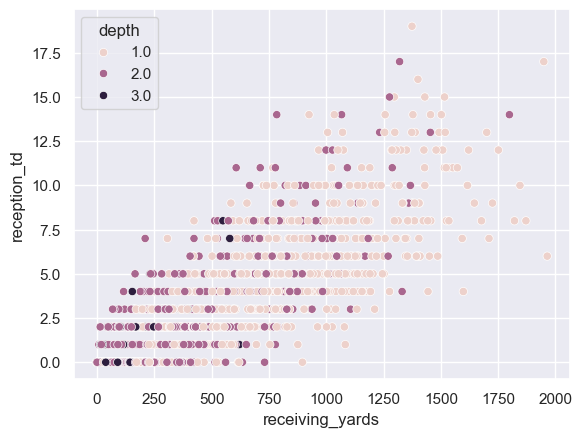

In [14]:
# Plot depth
sns.scatterplot(x = 'receiving_yards', y = 'reception_td', hue='depth', data = player)

Depth is a variable that describes the ranking of the player on the team. For example, if depth is 1 then the player is the #1 option to recieve the ball on the team. We can see that players who are #1 options are more likely to have more receiving yards and reception touchdowns. However, the #2 option can also get a lot of receiving yards. Thus, this may be a good variable to include in a model.

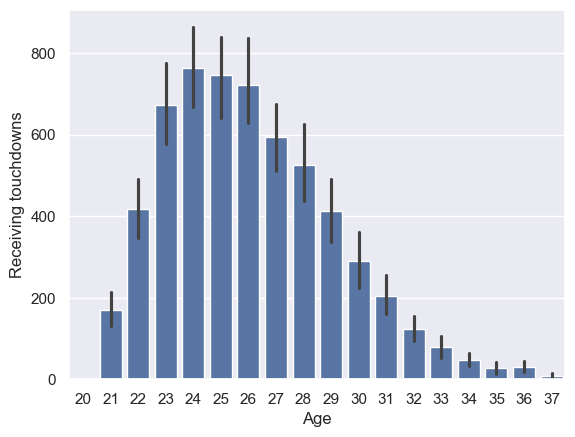

In [15]:
# Create variable for Age between 23-29
ax = sns.barplot(x="age", y="reception_td", data=player, estimator=sum)
ax.set(xlabel='Age', ylabel='Receiving touchdowns')

player['Age2229'] = (player['age'] >= 22) & (player['age'] <= 29)
player['Age2229'] = player['Age2229'].astype(int)

We can see that the prime age of a player is between 22 and 29 years old. As in that age range adheres the most receiving touchdowns.

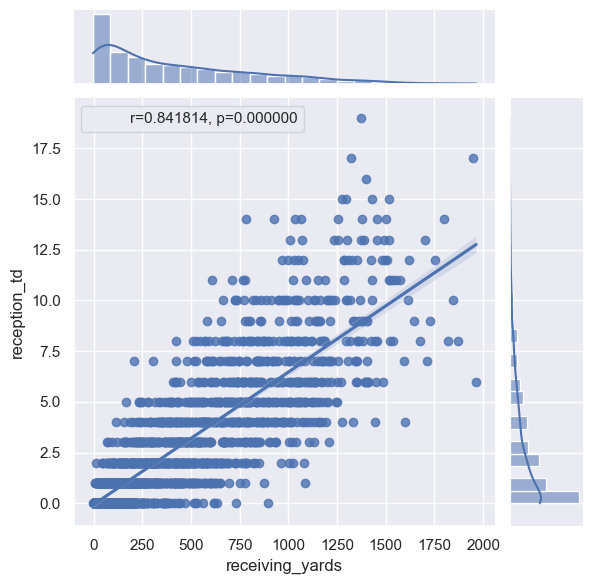

In [18]:
sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="receiving_yards", y="reception_td", kind='reg')

x=player['receiving_yards']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

We can see receiving yards is a good predictor of receiving touchdowns.

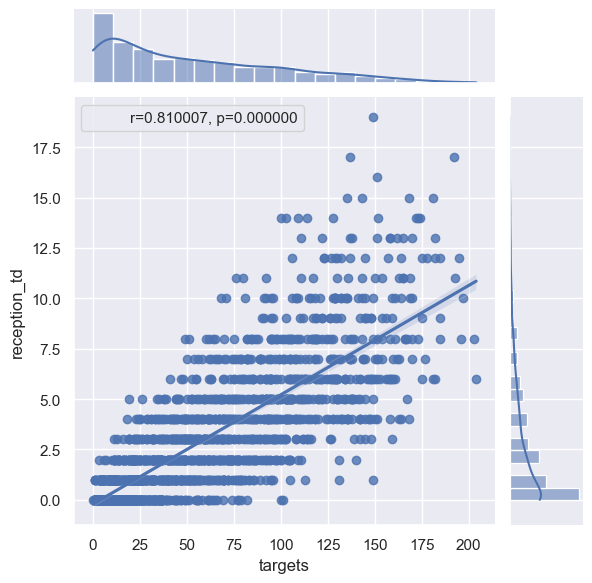

In [19]:
# Targets is also a positive correlation

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="targets", y="reception_td", kind='reg')

x=player['targets']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

In [20]:
x=player['targets']
y=player['receiving_yards']
correlation_matrix = np.corrcoef(x, y)
correlation_coefficient = correlation_matrix[0, 1]

print(correlation_coefficient)

0.9688221769384738


We see targets is also a great metric, but is highly correlated with receiving yards.

# The following are variables that are not correlated with reception touchdowns that we decided to not include

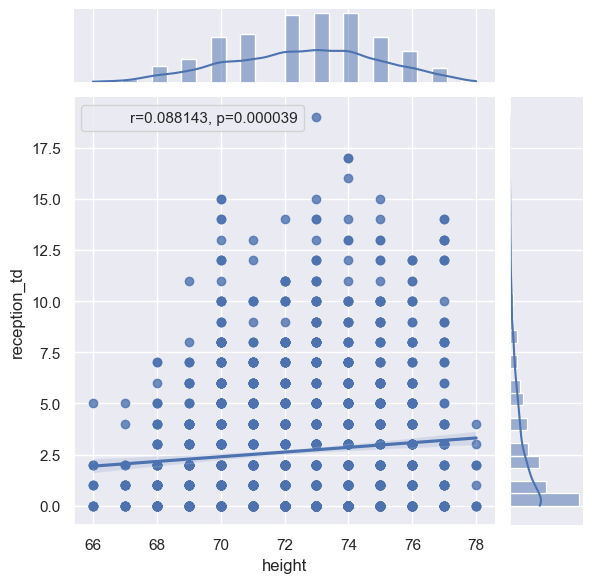

In [21]:
#Not a great correlation between height and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="height", y="reception_td", kind='reg')

x=player['height']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

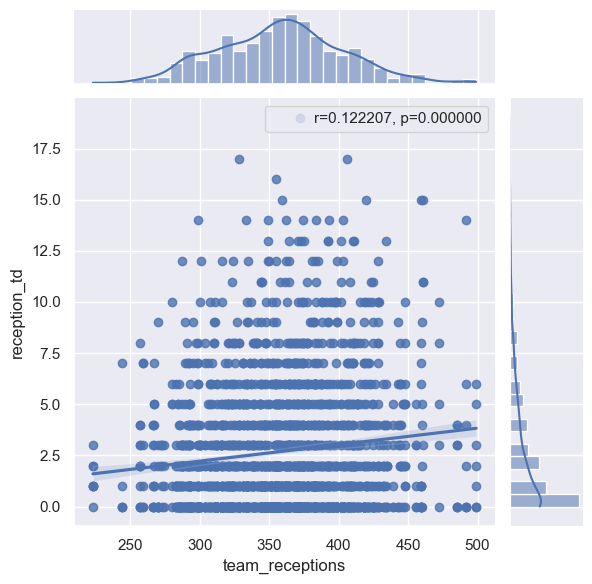

In [22]:
# Bad correlation between weight and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="team_receptions", y="reception_td", kind='reg')

x=player['weight']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

In [ ]:
# Not a great correlation between team passing yards and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="team_passing_yards", y="reception_td", kind='reg')

x=player['team_passing_yards']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

In [ ]:
# Not a great correlation between teams that pass and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="team_pass_td", y="reception_td", kind='reg')

x=player['team_pass_td']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

In [ ]:
# Not a great correlation between teams that pass and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="team_receptions", y="reception_td", kind='reg')

x=player['team_receptions']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

In [ ]:
# Not a great correlation between teams that pass and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="log_team_receiving_yards", y="reception_td", kind='reg')

x=player['team_receiving_yards']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

graph.ax_joint.set_xscale('log')
graph.ax_joint.set_yscale('log')

In [ ]:
# Not a great correlation between teams that pass and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="team_pass_snaps_count", y="reception_td", kind='reg')

x=player['team_pass_snaps_count']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])

In [ ]:
# Not a great correlation between teams that pass and touchdowns

sns.set(style="darkgrid", color_codes=True)
graph=sns.jointplot(data=player, x="team_pass_snaps_count", y="reception_td", kind='reg')

x=player['team_pass_snaps_count']
y=player['reception_td']
r, p = stats.pearsonr(x, y)
phantom, = graph.ax_joint.plot([], [], linestyle="", alpha=0)

graph.ax_joint.legend([phantom],['r={:f}, p={:f}'.format(r,p)])